In [3]:
import os 
import pandas as pd 
import json 
from collections import Counter

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

sns.set_theme(palette = "muted" )
# sns.palettes.color_palette("pastel")

## Datasets statistics

We have essentially 3 kind of questions:
- Direct question with question mark (?)
- Right continuation selection (with multiple dots, columns or nothing)
- Correct statement selection (ending with a dot)

In [4]:
base_dir_data = "./shuffled_mqa"

In [5]:
#load one shuffle per dataset to check statistics
all_data_unique = {}
all_data_shuffles = {}
for folder in os.listdir(base_dir_data):
    subfolder = os.path.join(base_dir_data, folder)
    all_data_shuffles[folder] = {}
    for shuffle in os.listdir(subfolder):
        shuffle_path = os.path.join(subfolder, shuffle)
        #todo make a single dict and filter afterward
        if shuffle.split(".")[0][-1] == "1":
            data = json.load(open(shuffle_path, "r"))
            # all_data.append(data)
            all_data_unique[folder] = data 
        
        data = json.load(open(shuffle_path, "r")) 
        all_data_shuffles[folder][shuffle] = data
    
    


In [6]:
#check the endings of the questions to see the kind of quetions
def check_endings(data):
    endings = []
    for k in data:
        end = data[k]["question_text"][-1]
        endings.append(end)
    distribution = Counter(endings)
    return distribution

for d in all_data_unique:
    end = check_endings(all_data_unique[d])
    print(f"\nAnswer endings for {d}")
    print(end)




Answer endings for proc_civile_ga
Counter({':': 432, '?': 366, '.': 2})

Answer endings for diritto_privato_ga
Counter({':': 518, '?': 266, '.': 14, 'i': 1, 'è': 1})

Answer endings for diritto_amm_ga
Counter({':': 274, '?': 260, '.': 255, '…': 23, 'i': 4, 'o': 3, 'a': 2, 'e': 2, '0': 1, ';': 1})

Answer endings for dir_proc_amm_ga
Counter({':': 448, '?': 319, '.': 28, 'e': 5, 'i': 2, 'o': 2, ')': 1, '…': 1})


In [7]:
# question length stats
question_lengths_char = []
question_lengths_wc = []
for d in all_data_unique:
    for q in all_data_unique[d]:
        question_lengths_char.append(len(all_data_unique[d][q]["question_text"]))
        question_lengths_wc.append(len(all_data_unique[d][q]["question_text"].split()))

    avg_char_len = sum(question_lengths_char) / len(question_lengths_char)
    avg_wc_len = sum(question_lengths_wc) / len(question_lengths_wc)
    print(f"\nAverage chars questions length for {d}: {round(avg_char_len,2)}")
    print(f"Average wc questions length for {d}: {round(avg_wc_len,2)}")



    


Average chars questions length for proc_civile_ga: 121.64
Average wc questions length for proc_civile_ga: 18.76

Average chars questions length for diritto_privato_ga: 111.29
Average wc questions length for diritto_privato_ga: 17.23

Average chars questions length for diritto_amm_ga: 120.77
Average wc questions length for diritto_amm_ga: 17.99

Average chars questions length for dir_proc_amm_ga: 115.94
Average wc questions length for dir_proc_amm_ga: 17.27


In [8]:
#TODO check distribution of correct answers across shuffles
def check_distribution_correct(data):
    corrects = []
    for question in data:
        corrects.append(data[question]["correct_answer"][0])
    return Counter(corrects)

for data in all_data_shuffles:
    print(f"\nCorrect answer distribution for {data}")
    for shuffle in all_data_shuffles[data]:
        print(f"Shuffle {shuffle.split(".")[0][-1]}:{check_distribution_correct(all_data_unique[data])} ")
    


Correct answer distribution for proc_civile_ga
Shuffle 2:Counter({'C': 220, 'D': 206, 'B': 198, 'A': 176}) 
Shuffle 3:Counter({'C': 220, 'D': 206, 'B': 198, 'A': 176}) 
Shuffle 1:Counter({'C': 220, 'D': 206, 'B': 198, 'A': 176}) 
Shuffle 4:Counter({'C': 220, 'D': 206, 'B': 198, 'A': 176}) 

Correct answer distribution for diritto_privato_ga
Shuffle 4:Counter({'A': 223, 'C': 211, 'B': 194, 'D': 172}) 
Shuffle 3:Counter({'A': 223, 'C': 211, 'B': 194, 'D': 172}) 
Shuffle 2:Counter({'A': 223, 'C': 211, 'B': 194, 'D': 172}) 
Shuffle 1:Counter({'A': 223, 'C': 211, 'B': 194, 'D': 172}) 

Correct answer distribution for diritto_amm_ga
Shuffle 4:Counter({'D': 215, 'C': 205, 'B': 203, 'A': 202}) 
Shuffle 3:Counter({'D': 215, 'C': 205, 'B': 203, 'A': 202}) 
Shuffle 2:Counter({'D': 215, 'C': 205, 'B': 203, 'A': 202}) 
Shuffle 1:Counter({'D': 215, 'C': 205, 'B': 203, 'A': 202}) 

Correct answer distribution for dir_proc_amm_ga
Shuffle 2:Counter({'B': 205, 'C': 203, 'A': 200, 'D': 198}) 
Shuffle 1:

## Results analysis

In [9]:
def compute_accuracy(df):
    correct = df["correct_answers"].tolist()
    predictions = df["model_answers"].tolist()
    accuracy = (len([i for i,e in zip(correct, predictions) if i == e]) / df.shape[0]) *100
    oos_answers = len([i for i in predictions if not i in ["A", "B", "C", "D"]]) / df.shape[0] *100
    return round(accuracy,2), round(oos_answers,5)

In [10]:
base_dir = "./evaluation/results"
dfs = []
df_rows = []
for model in os.listdir(base_dir):
    # if not "claude" in model:
    subdir = os.path.join(base_dir, model)
    for dataset in os.listdir(subdir):
        dataset_path = os.path.join(subdir,dataset)
        for shuffle in os.listdir(dataset_path):
            file_path = os.path.join(dataset_path, shuffle)
            
            df = pd.read_csv(file_path, sep = "\t")
            # dfs.append(df)
            shuffle_id  =shuffle.split(".")[0][-1]
            accuracy, oos_answers = compute_accuracy(df)
            row = (model.capitalize(), dataset, shuffle_id, accuracy, oos_answers)
            df_rows.append(row)
            # model, dataset, accuracy, out_of_scope_ansers

results = pd.DataFrame(df_rows, columns = ["model", "dataset", "shuffle", "accuracy", "oos_answers"])

results.head(20)

,model,dataset,shuffle,accuracy,oos_answers
0,Minerva-7b-instruct-v1.0,proc_civile_ga,2,37.50,0.000
1,Minerva-7b-instruct-v1.0,proc_civile_ga,4,37.38,0.000
2,Minerva-7b-instruct-v1.0,proc_civile_ga,1,39.38,0.000
3,Minerva-7b-instruct-v1.0,proc_civile_ga,3,39.25,0.000
4,Minerva-7b-instruct-v1.0,diritto_privato_ga,4,40.38,0.000
5,Minerva-7b-instruct-v1.0,diritto_privato_ga,2,38.50,0.000
6,Minerva-7b-instruct-v1.0,diritto_privato_ga,1,39.88,0.000
7,Minerva-7b-instruct-v1.0,diritto_privato_ga,3,40.38,0.000
8,Minerva-7b-instruct-v1.0,diritto_amm_ga,2,34.30,0.000
9,Minerva-7b-instruct-v1.0,diritto_amm_ga,3,32.97,0.000


/tmp/ipykernel_3079955/1217149698.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[n].set_xticklabels(axes[n].get_xticklabels(), rotation = 45, ha = "right")


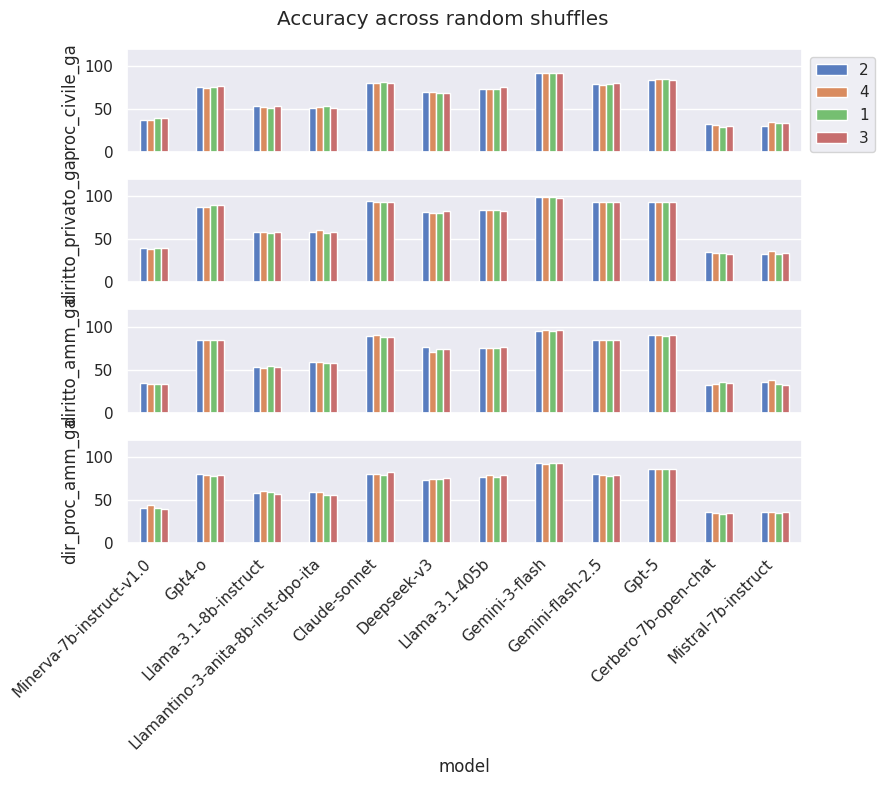

In [11]:

fig, axes = plt.subplots(4, 1, figsize = (9,8))
axes.flatten()
legend = True

for n,data in enumerate(results["dataset"].unique()):
    if n != 0:
        legend = False
    
    sns.barplot(results[results["dataset"] == data], y = "accuracy", x = "model", ax = axes[n], hue = "shuffle", legend = legend, 
                 palette = "muted", width= 0.5)

    axes[n].set_ylabel(data)
    axes[n].set_ylim(0, 120)
    
    if n == 0:
        axes[n].legend(bbox_to_anchor= (1,1))
    if not n == 3:
        axes[n].set_xticks([])
        axes[n].set_xlabel("")
    else:
        axes[n].set_xticklabels(axes[n].get_xticklabels(), rotation = 45, ha = "right")

    axes[n].margins(x=0.02)
    

plt.suptitle("Accuracy across random shuffles")

plt.tight_layout()
plt.show()

In [12]:
fig.get_figure().savefig("./accuracy.png")

In [13]:
results[(results["model"] == "Gemini-3-flash") & (results["dataset"] == "diritto_privato_ga")]["accuracy"].mean().round()

np.float64(99.0)

In [14]:
new_df_rows= []
for model in results["model"].unique():
    for dataset in results["dataset"].unique():

        avg = results[(results["model"] == model) & (results["dataset"] == dataset)]["accuracy"].mean().round(2).item()
        avg_oos = results[(results["model"] == model) & (results["dataset"] == dataset)]["oos_answers"].mean().round(1).item()
        new_df_rows.append((model, dataset, avg, avg_oos))
average_acc_df = pd.DataFrame(new_df_rows, columns = ["model", "dataset", "average_accuracy", "average_oos"])
average_acc_df.head()

,model,dataset,average_accuracy,average_oos
0,Minerva-7b-instruct-v1.0,proc_civile_ga,38.38,0.0
1,Minerva-7b-instruct-v1.0,diritto_privato_ga,39.78,0.0
2,Minerva-7b-instruct-v1.0,diritto_amm_ga,33.45,0.0
3,Minerva-7b-instruct-v1.0,dir_proc_amm_ga,41.22,0.0
4,Gpt4-o,proc_civile_ga,75.75,5.4


In [23]:
pivot_table = average_acc_df.pivot(index = "model", columns = "dataset", values = "average_accuracy")#.to_csv("./average_accuracy.csv")
pivot_table 

dataset,dir_proc_amm_ga,diritto_amm_ga,diritto_privato_ga,proc_civile_ga
model,,,,
Cerbero-7b-open-chat,34.46,33.66,33.81,31.22
Claude-sonnet,80.21,88.82,93.68,80.50
Deepseek-v3,73.88,73.67,81.81,69.69
Gemini-3-flash,92.37,95.36,98.66,92.44
Gemini-flash-2.5,78.60,84.76,93.22,79.47
Gpt-5,85.67,90.00,93.75,84.62
Gpt4-o,78.48,84.09,88.78,75.75
Llama-3.1-405b,77.39,75.55,83.75,73.84
Llama-3.1-8b-instruct,58.47,53.00,57.94,52.87


[Text(0.5, 1.0, 'Average performance of models across shuffles')]

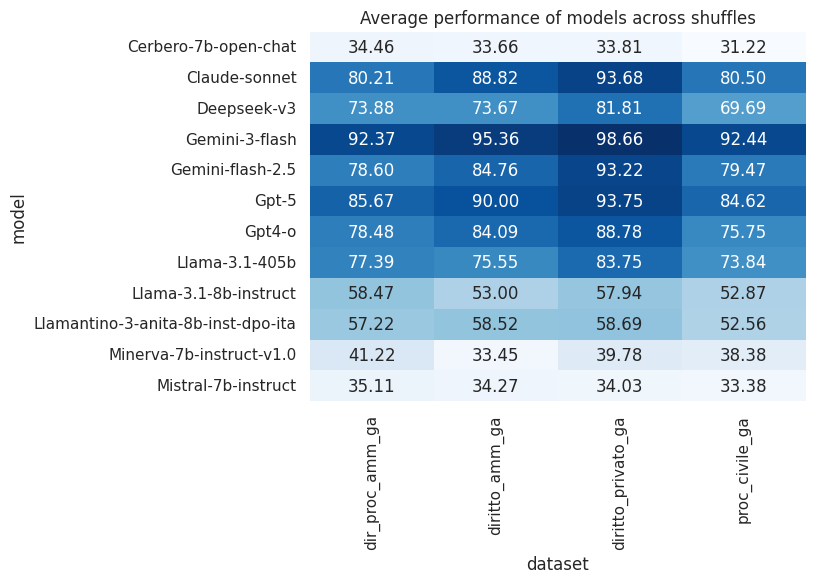

In [ ]:
sns.heatmap(pivot_table, cmap = "Blues", cbar = False, annot=True, fmt = ".2f").set(title="Average performance of models across shuffles");

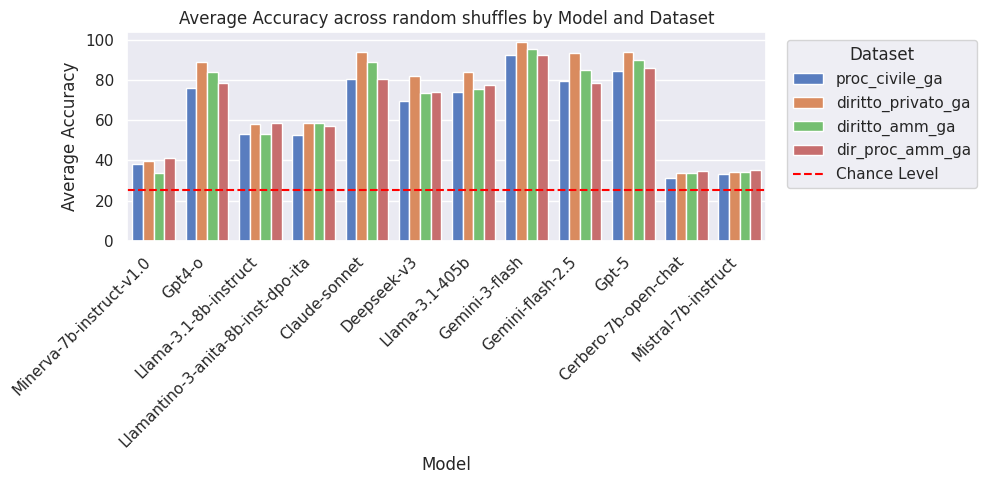

In [16]:
plt.figure(figsize=(10, 5))
sns.barplot(data=average_acc_df, x="model", y="average_accuracy", hue="dataset", palette="muted").set(title="Average Accuracy across random shuffles by Model and Dataset")
plt.xlabel("Model")
plt.ylabel("Average Accuracy")
plt.xticks(rotation=45, ha="right")
plt.axhline(y=25, color='red', linestyle='--', label='Chance Level')
plt.legend(title="Dataset", bbox_to_anchor=(1.02, 1), loc="upper left") # bbox_to_anchor=(1.02, 1)
#plt.ylim(0, 130) # bbox_to_anchor=(0.79, 1)

plt.tight_layout()
plt.show()

In [17]:
fig = px.line_polar(average_acc_df, r='average_accuracy', theta='dataset', line_close=True)
fig.update_traces(fill='toself')
fig.update_layout(
  polar=dict(
    radialaxis=dict(
      visible=True,
      range=[0, 100]
    )),
  showlegend=True
)
fig.show()

In [38]:
fig.update_traces(
    fill='toself',
    opacity=0.35,                  # lighter filled area
    line=dict(width=1.5)           # thinner outline
)

fig.update_layout(
    template="plotly_white",       # clean/light theme
    paper_bgcolor="white",
    plot_bgcolor="white",
    polar=dict(
        bgcolor="white",
        radialaxis=dict(
            visible=True,
            range=[0, 100],
            gridcolor="rgba(0,0,0,0.12)",   # lighter grid
            linecolor="rgba(0,0,0,0.25)",
            tickfont=dict(color="rgba(0,0,0,0.65)")
        ),
        angularaxis=dict(
            gridcolor="rgba(0,0,0,0.12)",
            linecolor="rgba(0,0,0,0.40)",
            tickfont=dict(color="rgba(0,0,0,0.65)")
        )
    ),
    showlegend=True,
    legend=dict(
        x=0.8,
        y=1.0,
        xanchor="left",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.7)"
    ),
    title=dict(
        text="Average Accuracy by Model and Dataset",
        x=0.5,           # center title
        xanchor="center"
    )
)
fig.show()

## Error analysis

Is there a ratio in the errors? 

## Answering Bias

In [20]:
INDIR = "./evaluation/results"